# 11_数据预处理方法-降维

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天分享的是数据预处理方法：降维。

降维就是“**减少数据的维度**”。简单来说，就是把原本有很多列的数据，变成更少列的数据，同时尽量保留原来的主要信息。

举个简单的例子：

假设你做了一个关于人的健康调查，包括以下三项：

1. 身高
2. 体重
3. BMI（体重指数）

其实 BMI 是由身高和体重计算出来的，所以它并不是真正额外的独立信息。这时你可以选择只保留身高和体重，或者只保留 BMI。这样就减少了数据的维度，这就是降维的一种方式。

**为什么要降维？**

1. 数据维度太高，会增加模型复杂度，容易导致“过拟合”，影响模型的泛化能力。
2. 降维后计算更快，节省资源。
3. 降维可以帮助我们把高维数据转成2维或3维，更容易可视化。
4. 有些特征（列）可能是重复的、噪声太多的、或者对最终分析没有帮助的，去掉它们可以提高效率和效果。

咱们在实验中，常用的降维方法：

1. 主成分分析（PCA）：找到最能代表数据的方向，把数据投影到这些方向上，去掉影响小的部分。
2. 线性判别分析（LDA）：用于分类问题，寻找最能区分不同类别的数据方向。
3. 特征选择：用统计方法筛选出最重要的特征，去掉不重要的。
4. t-SNE、UMAP：主要用于把高维数据降到2维或3维，方便画图观察数据的分布结构。

总之，就是降维就是在不影响整体分析效果的前提下，把多余的、重复的或不重要的数据列去掉，让数据更精炼，更好处理。

## 原理详解

这里，咱们就用主成分分析（PCA）进行系统的讲解\~

在数据集中，假设我们有一个 $n \times d$ 的数据矩阵 $X$，其中：

- $n$：样本个数（行数）
- $d$：特征维度（列数）

我们希望将原始数据从 $d$ 维降到 $k$ 维（$k < d$），使得：

1. 降维后信息尽量不丢失；
2. 新的维度（主成分）是原始特征的线性组合；
3. 降维后的数据在这些新方向上的**方差最大**，因为方差越大代表信息越多。

#### 基本数学思想

PCA 的核心思想是：

- **寻找一组新的坐标轴方向（正交向量），使得数据投影到这些方向上具有最大的方差**；
- 新方向是原始变量的线性组合；
- 这些方向就是数据协方差矩阵的主特征向量。

### 公式推理

#### Step 1：数据中心化（均值归一）

我们要消除不同变量的偏移（即中心不一致），所以首先将每个特征减去其平均值：


$$
\tilde{X} = X - \mu
$$


其中，$\mu = \frac{1}{n} \sum_{i=1}^{n} X_i$，是每列（每个特征）的均值。

中心化后，每列的平均值是 0。

#### Step 2：计算协方差矩阵

协方差矩阵衡量不同特征之间的相关性。定义如下：


$$
C = \frac{1}{n-1} \tilde{X}^T \tilde{X}
$$


- $C$ 是 $d \times d$ 的对称矩阵；
- $C_{ij}$ 表示第 $i$ 个特征和第 $j$ 个特征的协方差。

#### Step 3：计算特征值和特征向量（谱分解）

我们需要对协方差矩阵 $C$ 做**特征值分解**：


$$
C \mathbf{v}_i = \lambda_i \mathbf{v}_i
$$


其中：

- $\mathbf{v}_i$：协方差矩阵的第 $i$ 个特征向量；
- $\lambda_i$：对应的特征值；
- 所有特征向量 $\mathbf{v}_i$ 两两正交，即 $\mathbf{v}_i^T \mathbf{v}_j = 0$（如果 $i \ne j$）。

特征值表示数据在对应方向上的“方差大小”，我们希望保留最大的前 $k$ 个。

#### Step 4：选取主成分方向

将特征值从大到小排序，选择前 $k$ 个最大的特征值所对应的特征向量：


$$
W = [\mathbf{v}_1, \mathbf{v}_2, ..., \mathbf{v}_k]
$$


此时 $W$ 是一个 $d \times k$ 的矩阵，称为**投影矩阵**。

#### Step 5：进行降维变换

把原始的中心化数据 $\tilde{X}$ 投影到主成分方向上：


$$
Z = \tilde{X} W
$$


其中：

- $Z$ 是降维后的数据（维度为 $n \times k$）；
- 每一行是一个样本的新表示。

### 目标函数的优化推导

**想法：我们希望数据投影后，方差最大**

定义投影方向为一个单位向量 $\mathbf{w}$，数据为 $\tilde{X}$，我们希望最大化：


$$
\text{Var}(\tilde{X} \mathbf{w}) = \mathbf{w}^T C \mathbf{w}
$$


目标：$\max_{\mathbf{w}} \quad \mathbf{w}^T C \mathbf{w} \quad \text{subject to } \mathbf{w}^T \mathbf{w} = 1$

这是一个典型的带约束的优化问题，可以用拉格朗日乘子法求解：

定义拉格朗日函数：


$$
L(\mathbf{w}, \lambda) = \mathbf{w}^T C \mathbf{w} - \lambda(\mathbf{w}^T \mathbf{w} - 1)
$$


对 $\mathbf{w}$ 求导并令导数为零：


$$
\nabla_{\mathbf{w}} L = 2C\mathbf{w} - 2\lambda \mathbf{w} = 0 \Rightarrow C\mathbf{w} = \lambda \mathbf{w}
$$


这正是特征值分解的定义。

所以，**最大方差对应最大特征值，其方向为对应的特征向量。**

## 完整案例

在机器学习和数据科学中，特征维度过高可能带来“维度灾难”，如模型训练速度慢、过拟合风险增加、可视化困难等问题。PCA 是最常用的线性降维方法，通过最大化数据方差投影，提取最有信息量的主成分。

我们使用经典的 Iris（鸢尾花）数据集，演示 PCA 如何对高维特征进行降维并进行可视化分析，同时评估其在分类任务中的表现。

#### 数据集

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = y

- `iris.data`: 包含 150 个样本，每个样本有 4 个特征；
- `iris.target`: 分类标签（0, 1, 2）分别代表 Setosa、Versicolor、Virginica；
- `iris.feature_names`: ['sepal length', 'sepal width', 'petal length', 'petal width']。

#### 可视化原始数据的特征分布

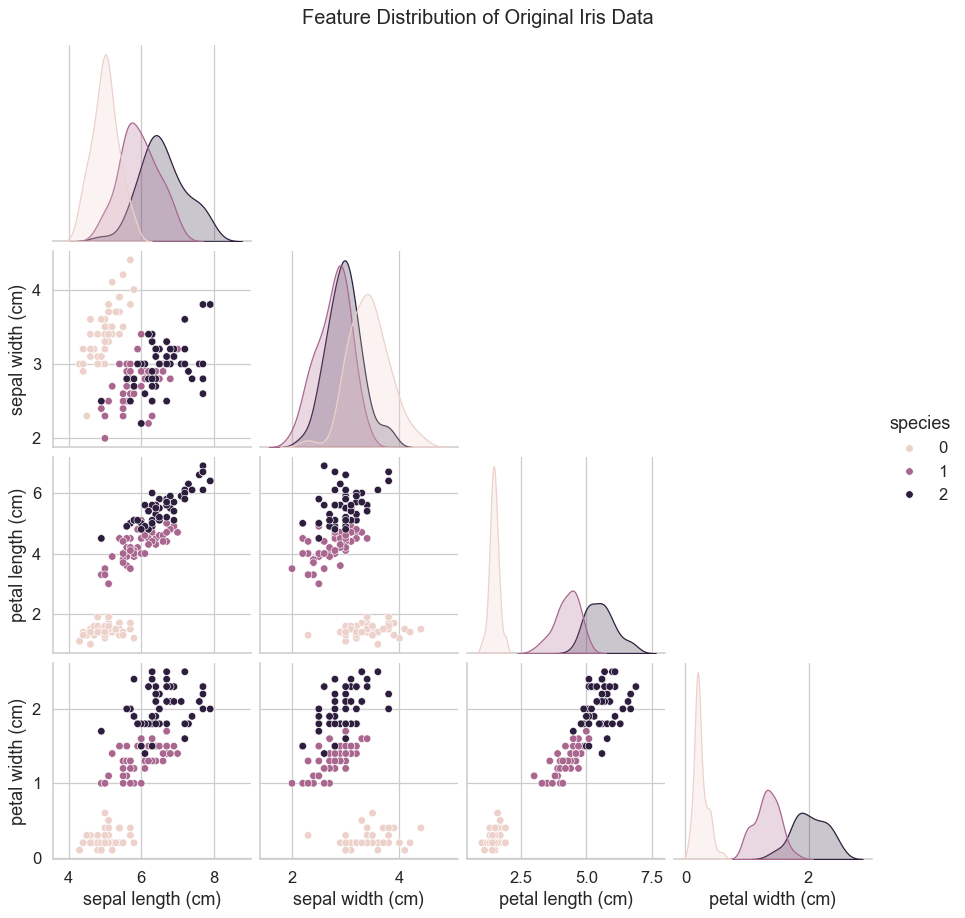

In [3]:
sns.set(style="whitegrid", palette="bright", font_scale=1.2)
plt.rcParams['font.sans-serif'] = CJK_FONTS
sns.pairplot(df, hue='species', corner=True)
plt.suptitle("Feature Distribution of Original Iris Data", fontsize=16, y=1.02)
plt.show()

- 使用 `pairplot` 查看特征之间的分布和相关性；
- 从图中可见，有些特征（如 petal length）能较好区分类别，有些则重叠较多。

![原文参考图，当前结果见代码输出](attachments/img_001.png)

#### 数据标准化处理

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

- PCA 对原始量纲敏感，因此需要标准化；
- `StandardScaler` 将每列特征转换为均值为 0，标准差为 1 的分布。

### 应用 PCA 降维

**步骤 1：拟合 PCA 模型并查看解释方差**

In [5]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_var_ratio)

Explained Variance Ratio: [0.72962445 0.22850762 0.03668922 0.00517871]


输出：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
Explained Variance Ratio: [0.72962445 0.22850762 0.03668922 0.00517871]
```

- 第一主成分解释了 72.9% 的信息；
- 前两主成分加起来可以解释约 96% 的信息，说明我们可以有效地降维到二维。

**步骤 2：可视化累计方差解释率**

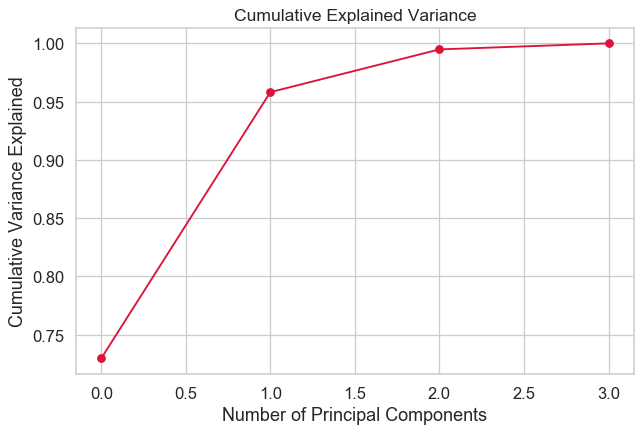

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_var_ratio), marker='o', color='crimson')
plt.title("Cumulative Explained Variance", fontsize=14)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.grid(True)
plt.show()

- 累计解释率曲线是选择主成分数的依据；
- 前两个分量达到信息饱和点，后面增益小。

![原文参考图，当前结果见代码输出](attachments/img_002.png)

**步骤 3：投影到二维主成分空间进行可视化**

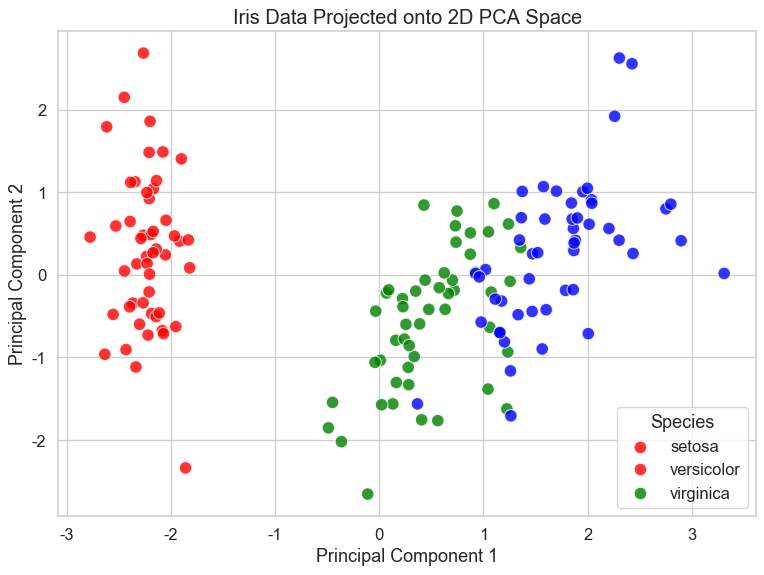

In [7]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_2d, columns=["PC1", "PC2"])
df_pca["species"] = y

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="species",
    palette=["red", "green", "blue"],
    alpha=0.8,
    s=100
)
plt.title("Iris Data Projected onto 2D PCA Space", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Species", labels=target_names)
plt.grid(True)
plt.show()

- Setosa 与其他类区别明显；
- Versicolor 和 Virginica 有一定重叠。

![原文参考图，当前结果见代码输出](attachments/img_003.png)

### 降维后建模与评估

**步骤 1：训练分类模型**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.2, random_state=42)

model = LogisticRegression(multi_class="ovr", max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


**步骤 2：评估模型性能**

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.78      0.88         9
   virginica       0.85      1.00      0.92        11

    accuracy                           0.93        30
   macro avg       0.95      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



- 虽然只保留了两个主成分，但模型准确率仍然很高（一般可达 90%+）；
- 显示 PCA 能有效提取关键特征。

### PCA 降维结构分析与可视化

**每个主成分的系数（载荷）**

<Figure size 720x540 with 0 Axes>

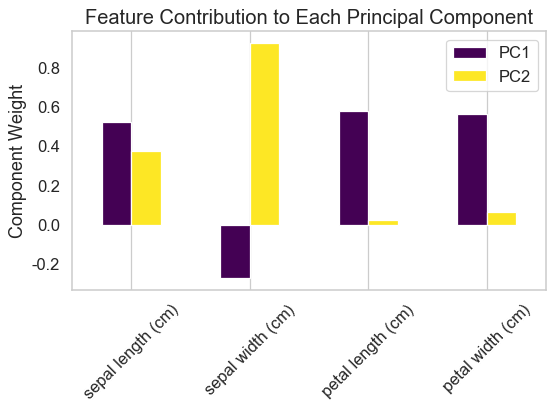

In [10]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1", "PC2"],
    index=feature_names
)

plt.figure(figsize=(8, 6))
loadings.plot(kind="bar", colormap="viridis")
plt.title("Feature Contribution to Each Principal Component", fontsize=16)
plt.ylabel("Component Weight")
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- 第一主成分主要依赖于 petal length、petal width；
- 说明这两个特征对分类贡献最大。

![原文参考图，当前结果见代码输出](attachments/img_004.png)

### 算法优化与高级技巧

**1. 使用 `whiten=True`（特征白化）**

In [11]:
pca_whiten = PCA(n_components=2, whiten=True)
X_white = pca_whiten.fit_transform(X_scaled)

将每个主成分的方差统一为 1，消除单位不一致的问题，适合某些模型（如 KMeans）。

**2. 可替代方案：使用 Kernel PCA（非线性降维）**

In [12]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(n_components=2, kernel='rbf')
X_kpca = kpca.fit_transform(X_scaled)

若数据分布非线性，普通 PCA 效果差，Kernel PCA 可映射到高维空间后再线性降维。

**3. 选择主成分数的自动化判断：保持 95% 方差信息**

In [13]:
pca_auto = PCA(n_components=0.95)
X_auto = pca_auto.fit_transform(X_scaled)
print("Selected components:", pca_auto.n_components_)

Selected components: 2


自动选择能保留 95% 信息量的主成分数量，平衡维度与信息保留。

## 模型分析

### 优缺点分析

**优点：**

1. **计算效率高，适合大多数数据集**：PCA 是线性降维方法，数学形式明确，通过特征协方差矩阵分解得到主成分，因此计算效率高，尤其适合高维但样本量适中的数据（如文本特征、图像特征等）。
2. **保留最大信息量（方差最大）**：主成分按解释方差排序，前几个主成分通常可以保留数据大部分的信息（本案例中前两个主成分保留了 96% 信息）。
3. **减少过拟合风险，提升泛化能力**：降维后的特征较少，有助于提升模型的稳定性，尤其在样本量不大的情况下效果明显。
4. **可视化性强**：将高维特征压缩至二维或三维，方便观察数据分布、类别边界，有助于探索性数据分析（EDA）和演示解释。
5. **与标准建模流程无缝集成**：可作为管道中数据预处理的一环，便于与 sklearn 的 Pipeline 配合使用。

**缺点：**

1. **仅适用于线性变换，不能处理非线性结构**：如果特征之间存在复杂的非线性关系，PCA 无法捕捉，比如图像、语音等天然存在非线性结构的数据。
2. **主成分不具可解释性**：PCA 得到的新特征（主成分）是原始特征的线性组合，含义不再直观，这在特征解释性要求较高的场景（如金融风控、医疗诊断）可能成为障碍。
3. **对异常值敏感**：PCA 依赖方差的计算，极端值会极大影响协方差矩阵，从而干扰主成分提取的准确性。
4. **降维是不可逆操作（信息丢失）**：原始特征信息可能在降维过程中部分丢失，因此在某些精度要求高的场景（如医学影像）中需要慎用。
5. **需要标准化处理**：PCA 对量纲敏感，不进行标准化处理会导致主成分偏向于值域大的特征。

### 与其他常见降维算法对比

| 降维方法 | 是否线性 | 是否可还原 | 是否可解释 | 是否支持非线性结构 | 计算复杂度 | 特点/适用场景 |
|-|-|-|-|-|-|-|
| **PCA** | ✅ 线性 | ❌ 不可还原 | ❌ 难以解释 | ❌ 不支持非线性 | ⭐ 快速 | 信息保留好，适合线性结构、可视化、压缩 |
| **LDA** | ✅ 线性 | ❌ 不可还原 | ✅ 可解释 | ❌ 不支持非线性 | ⭐ 快速 | 监督式降维，适用于分类问题 |
| **t-SNE** | ❌ 非线性 | ❌ 不可还原 | ❌ 不可解释 | ✅ 支持复杂结构 | ⚠️ 慢 | 可视化极强，但不可用于建模或部署 |
| **UMAP** | ❌ 非线性 | ❌ 不可还原 | ❌ 不可解释 | ✅ 支持复杂结构 | ⭐⭐ 中等 | 更快的 t-SNE 替代方案，聚类效果优于 t-SNE |
| **AutoEncoder** | ❌ 非线性 | ✅ 可还原 | ❌ 难以解释 | ✅ 支持非线性 | ⚠️ 慢+需训练 | 需要深度学习框架，适合大规模复杂数据 |
| **Kernel PCA** | ❌ 非线性 | ❌ 不可还原 | ❌ 难以解释 | ✅ 支持非线性 | ⭐⭐ 中等 | 使用核函数扩展 PCA，适合非线性场景 |

---

### 在什么情况下优选使用 PCA？什么时候考虑其他方法？

**PCA 是优选方法的场景：**

- **目标是信息压缩或可视化**，且对可解释性要求不高；
- **特征之间近似线性相关**，如大多数结构化数据；
- **需要快速预处理大规模数据**，如输入为 TF-IDF 文本特征、统计型金融数据；
- **用于分类、聚类等建模前的降维处理**；
- **后续模型为线性模型或对特征正交性敏感的算法**（如逻辑回归、KNN、KMeans）；
- **希望减少维度防止过拟合**（尤其在特征数 > 样本数时）。

**考虑其他方法的场景：**

- **数据存在明显非线性结构**（如图像中同类样本聚集但非线性分布），可选：

  - Kernel PCA（轻量非线性）
  - t-SNE / UMAP（强可视化）
  - AutoEncoder（适合大数据）
- **对可解释性有强需求**（如医疗、金融），推荐：

  - LDA（有监督，保留类别间差异）
  - 原始特征选择方法（如 Lasso、互信息等）
- **用于最终部署或模型预测阶段的输入特征**，建议不要使用 t-SNE/UMAP（不可还原，结果不稳定），此时优选：PCA / AutoEncoder（可稳定映射新样本）

## 总结

PCA 是降维领域中最基础且高效的方法，在结构化数据、模型预处理和可视化分析中具有极高的实用价值。但在非线性场景、可解释性强需求下，应考虑使用更适合的替代方法（如 LDA、UMAP、AutoEncoder）。选择降维算法时需平衡**计算成本、信息保留、解释性、可视化需求**等多种因素。